# Hate Speech Detection Using Machine Learning

**Authors:** Jonathan Bergkvist & Aleksandra Davidova Stefanova

---

## 1. Business / Research Problem

Hate speech and offensive language on social media platforms have become a serious societal issue. Millions of posts are published daily, making manual moderation unrealistic and inefficient. Automated hate speech detection using machine learning can help platforms:
- Identify harmful content
- Protect users from harassment
- Reduce the spread of toxic language

**Research Question:** How effectively can machine learning models detect and classify hate speech in text data?

## 2. Hypotheses

- **H1:** Traditional machine learning models such as Logistic Regression combined with TF-IDF feature extraction can achieve strong baseline performance in hate speech detection.
- **H2:** More advanced models (e.g., Random Forest or Support Vector Machine) may improve classification performance in terms of precision, recall, and F1-score.

---
## 3. Setup and Imports

In [ ]:
# Project dependencies
# !pip install kagglehub[pandas-datasets] pandas numpy scikit-learn matplotlib seaborn nltk wordcloud
!pip install tensorflow transformers torch scikit-learn

In [ ]:
# ============================================================
# 3) Setup and Imports
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# Standard library
# ------------------------------------------------------------
import os
import re
import string

# ------------------------------------------------------------
# Data handling
# ------------------------------------------------------------
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ------------------------------------------------------------
# NLP / Text preprocessing
# ------------------------------------------------------------
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ------------------------------------------------------------
# Classical ML / data splitting / evaluation
# ------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

# ------------------------------------------------------------
# Deep Learning: TensorFlow / Keras for LSTM
# ------------------------------------------------------------
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# ------------------------------------------------------------
# Transformers / PyTorch for BERT
# ------------------------------------------------------------
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

# ------------------------------------------------------------
# Download NLTK resources
# ------------------------------------------------------------
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# ------------------------------------------------------------
# Plot style
# ------------------------------------------------------------
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All imports successful!')

All imports successful!


---
## 4. Load the Dataset

We use the [Hate Speech and Offensive Language Dataset](https://www.kaggle.com/datasets/mrmorj/hate-speech-and-offensive-language-dataset) from Kaggle, loaded via the Kaggle API.

In [ ]:
import kagglehub

# Download the dataset from Kaggle
dataset_path = kagglehub.dataset_download("mrmorj/hate-speech-and-offensive-language-dataset")
csv_path = os.path.join(dataset_path, "labeled_data.csv")

# Load with pandas (encoding='latin-1' needed for this dataset)
df = pd.read_csv(csv_path, encoding='latin-1')

print(f'Dataset shape: {df.shape}')
df.head()

Using Colab cache for faster access to the 'hate-speech-and-offensive-language-dataset' dataset.
Dataset shape: (24783, 7)


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [ ]:
# Basic info about the dataset
print('--- Dataset Info ---')
print(df.info())
print('\n--- Column Names ---')
print(df.columns.tolist())
print('\n--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())
print('\n--- Descriptive Statistics ---')
df.describe()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB
None

--- Column Names ---
['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']

--- Data Types ---
Unnamed: 0             int64
count                  int64
hate_speech            int64
offensive_language     int64
neither                int64
class                  int64
tweet                 object
dtype: object

--- Missing Values ---
Unnamed: 0 

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.110277
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.462089
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


---
## 5. Exploratory Data Analysis (EDA)

The dataset uses the following class labels:
- **0** = Hate Speech
- **1** = Offensive Language
- **2** = Neither

In [ ]:
# Map numeric class labels to readable names
class_map = {0: 'Hate Speech', 1: 'Offensive Language', 2: 'Neither'}
df['class_label'] = df['class'].map(class_map)

print('--- Class Distribution ---')
print(df['class_label'].value_counts())
print()
print(df['class_label'].value_counts(normalize=True).round(4) * 100)

--- Class Distribution ---
class_label
Offensive Language    19190
Neither                4163
Hate Speech            1430
Name: count, dtype: int64

class_label
Offensive Language    77.43
Neither               16.80
Hate Speech            5.77
Name: proportion, dtype: float64


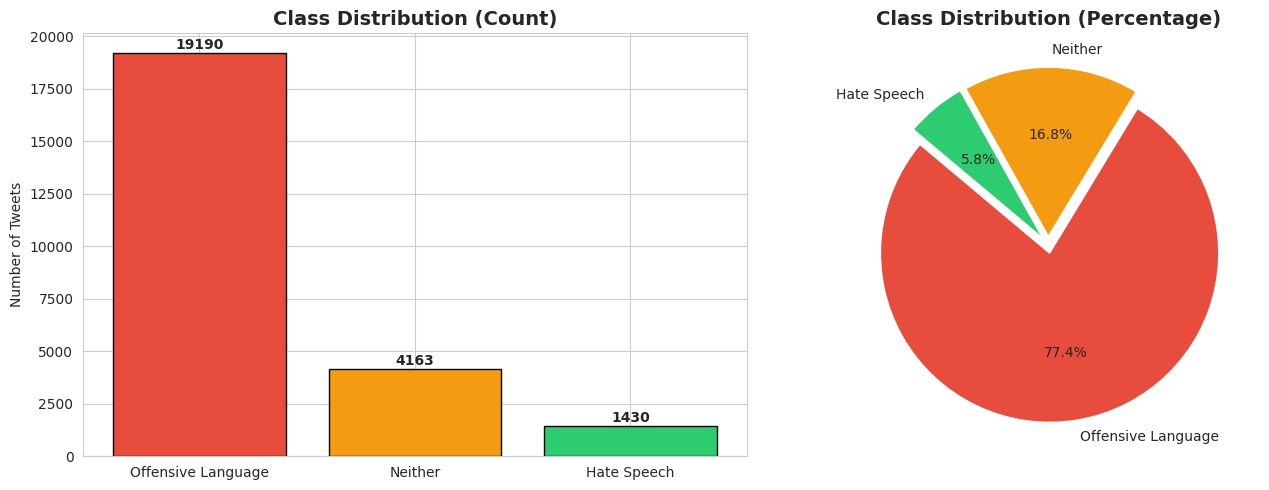

Note: The dataset is highly imbalanced — offensive language dominates.


In [ ]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_counts = df['class_label'].value_counts()
colors = ['#e74c3c', '#f39c12', '#2ecc71']
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Tweets')
for i, (label, count) in enumerate(zip(class_counts.index, class_counts.values)):
    axes[0].text(i, count + 200, str(count), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, explode=(0.05, 0.05, 0.05))
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: The dataset is highly imbalanced \u2014 offensive language dominates.')

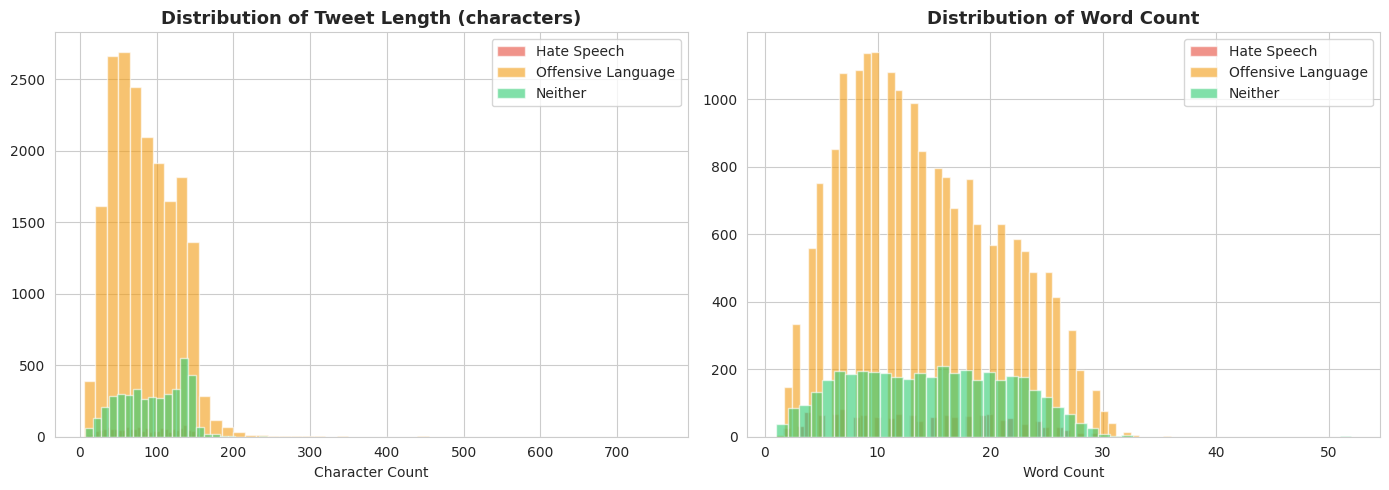

In [ ]:
# Tweet length analysis
df['tweet_length'] = df['tweet'].apply(len)
df['word_count'] = df['tweet'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in zip(['Hate Speech', 'Offensive Language', 'Neither'], colors):
    subset = df[df['class_label'] == label]
    axes[0].hist(subset['tweet_length'], bins=50, alpha=0.6, label=label, color=color)
    axes[1].hist(subset['word_count'], bins=50, alpha=0.6, label=label, color=color)

axes[0].set_title('Distribution of Tweet Length (characters)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].legend()

axes[1].set_title('Distribution of Word Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

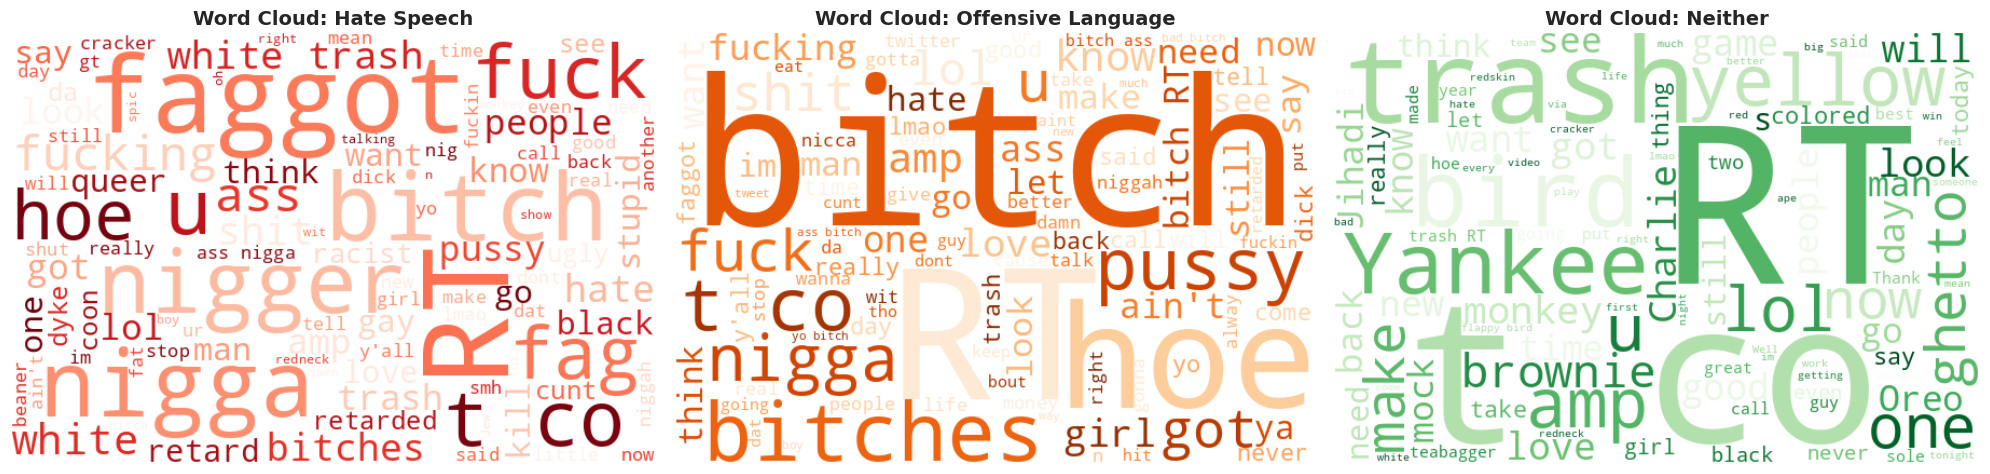

In [ ]:
# Word clouds per class
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (label, color_map) in enumerate(
    zip(['Hate Speech', 'Offensive Language', 'Neither'],
        ['Reds', 'Oranges', 'Greens'])):
    text = ' '.join(df[df['class_label'] == label]['tweet'].values)
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=color_map, max_words=100).generate(text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {label}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Text Preprocessing

**Steps**

### For LSTM preprocessing (`clean_tweet`)

1. Convert the tweet text to a string to ensure consistent processing.  
2. Convert all text to lowercase.  
3. Remove URLs (e.g., links starting with `http`, `https`, or `www`).  
4. Remove user mentions such as `@username`.  
5. Remove the hashtag symbol `#` while keeping the word itself.  
6. Remove numbers, punctuation, and other special characters.  
7. Split the text into individual words (tokenization).  
8. Remove common English stopwords.  
9. Join the cleaned words back into a single sentence.  
10. Remove extra spaces from the text.

### For BERT preprocessing (`bert_text`)

1. Convert the tweet text to a string.  
2. Remove URLs from the text.  
3. Remove user mentions such as `@username`.  
4. Keep punctuation and most of the original wording to preserve context.  
5. Remove extra spaces.


In [ ]:
# Create a set of English stopwords
stop_words = set(stopwords.words('english'))


# ------------------------------------------------------------
# Cleaning function for LSTM
# ------------------------------------------------------------
# For LSTM we apply more preprocessing:
# - lowercase text
# - remove URLs
# - remove mentions
# - remove hashtag symbol but keep the word
# - remove punctuation / digits
# - remove stopwords
# - remove extra spaces

def clean_text_lstm(text):

    # Ensure text is string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove Twitter mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol but keep the word
    text = re.sub(r"#", "", text)

    # Remove punctuation, digits and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words back together
    text = " ".join(words)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# ------------------------------------------------------------
# Cleaning function for BERT
# ------------------------------------------------------------
# BERT requires minimal preprocessing because it uses its
# own tokenizer and language understanding.

def clean_text_bert(text):

    # Ensure text is string
    text = str(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# ------------------------------------------------------------
# Apply preprocessing to dataset
# ------------------------------------------------------------

df["clean_tweet"] = df["tweet"].apply(clean_text_lstm)
df["bert_text"] = df["tweet"].apply(clean_text_bert)


# ------------------------------------------------------------
# Preview results
# ------------------------------------------------------------

print(df[["tweet", "clean_tweet", "bert_text"]].head())


# ------------------------------------------------------------
# Check for missing values
# ------------------------------------------------------------

print("\nMissing values in clean_tweet:", df["clean_tweet"].isnull().sum())
print("Missing values in bert_text:", df["bert_text"].isnull().sum())


# ------------------------------------------------------------
# Check for empty strings
# ------------------------------------------------------------

print("\nEmpty clean_tweet rows:", (df["clean_tweet"].str.strip() == "").sum())
print("Empty bert_text rows:", (df["bert_text"].str.strip() == "").sum())

                                               tweet  \
0  !!! RT @mayasolovely: As a woman you shouldn't...   
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...   
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...   
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...   
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...   

                                         clean_tweet  \
0  rt woman shouldnt complain cleaning house amp ...   
1  rt boy dats coldtyga dwn bad cuffin dat hoe st...   
2  rt dawg rt ever fuck bitch start cry confused ...   
3                                rt look like tranny   
4  rt shit hear might true might faker bitch told ya   

                                           bert_text  
0  !!! RT : As a woman you shouldn't complain abo...  
1  !!!!! RT : boy dats cold...tyga dwn bad for cu...  
2  !!!!!!! RT Dawg!!!! RT : You ever fuck a bitch...  
3              !!!!!!!!! RT : she look like a tranny  
4  !!!!!!!!!!!!! RT : The shit you hear about me ..

---
## 7. Feature Extraction

In deep learning models like LSTM and BERT, we do not create
Bag-of-Words or TF-IDF features. Instead, we prepare the text
directly for the models.


In [ ]:
# LSTM will use the cleaned text
X_lstm = df["clean_tweet"]

# BERT will use minimally processed text
X_bert = df["bert_text"]

# Target variable (labels)
y = df["class"]


In [ ]:
# ------------------------------------------------------------
# Create a train/test split
# We split indices so that both LSTM and BERT use the same data
# ------------------------------------------------------------

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Prepare LSTM datasets
# ------------------------------------------------------------

X_train_lstm = df.loc[train_idx, "clean_tweet"]
X_test_lstm = df.loc[test_idx, "clean_tweet"]

# ------------------------------------------------------------
# Prepare BERT datasets
# ------------------------------------------------------------

X_train_bert = df.loc[train_idx, "bert_text"]
X_test_bert = df.loc[test_idx, "bert_text"]

# ------------------------------------------------------------
# Labels for both models
# ------------------------------------------------------------

y_train = df.loc[train_idx, "class"]
y_test = df.loc[test_idx, "class"]


# ------------------------------------------------------------
# Print dataset sizes to verify the split
# ------------------------------------------------------------

print("Training samples:", len(train_idx))
print("Testing samples:", len(test_idx))

print("\nTraining class distribution:")
print(y_train.value_counts())

Training samples: 19826
Testing samples: 4957

Training class distribution:
class
1    15352
2     3330
0     1144
Name: count, dtype: int64


---
## 8. Model Training and Evaluation

In this section, we:
1. Prepare tokenized and padded sequences for the LSTM model
2. Build and train the LSTM model
3. Prepare the dataset for BERT / DistilBERT
4. Train and evaluate the BERT model
5. Store the results so they can be compared later

In [ ]:
# ------------------------------------------------------------
# 8.1 Prepare LSTM input data
# ------------------------------------------------------------

def prepare_lstm_data(X_train_text, X_test_text, max_words=20000, max_len=50):
    """
    Convert training and test text into padded integer sequences
    for the LSTM model.
    """

    tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
    tokenizer.fit_on_texts(X_train_text)

    X_train_seq = tokenizer.texts_to_sequences(X_train_text)
    X_test_seq = tokenizer.texts_to_sequences(X_test_text)

    X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
    X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

    vocab_size = min(max_words, len(tokenizer.word_index) + 1)

    return tokenizer, X_train_pad, X_test_pad, vocab_size


# ------------------------------------------------------------
# 8.2 Build the LSTM model
# ------------------------------------------------------------

def build_lstm_model(vocab_size, embedding_dim=128, num_classes=3):
    """
    Build a Bidirectional LSTM model for multi-class classification.
    """

    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim),
        Bidirectional(LSTM(64)),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ------------------------------------------------------------
# 8.3 Train the LSTM model
# ------------------------------------------------------------

def train_lstm_model(X_train_pad, y_train, vocab_size, epochs=5, batch_size=32):
    """
    Train the LSTM model using class weights to reduce class imbalance.
    """

    class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train
    )

    class_weights = {
        cls: weight for cls, weight in zip(np.unique(y_train), class_weights_array)
    }

    model = build_lstm_model(vocab_size=vocab_size)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_pad,
        y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=1
    )

    return model, history



In [ ]:
# ------------------------------------------------------------
# 8.4 Evaluate the LSTM model
# ------------------------------------------------------------

def evaluate_lstm_model(model, X_test_pad, y_test, model_name="Bidirectional LSTM"):
    """
    Evaluate the LSTM model and print metrics in the same style
    as the original notebook.
    """

    y_prob = model.predict(X_test_pad)
    y_pred = np.argmax(y_prob, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    print("\n============================================================")
    print("Feature Extraction: clean_tweet")
    print("============================================================")
    print(f"\n--- {model_name} ---")
    print(f"Accuracy:     {accuracy:.4f}")
    print(f"F1 (Macro):   {f1_macro:.4f}")
    print(f"F1 (Weighted):{f1_weighted:.4f}\n")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Hate Speech", "Offensive Language", "Neither"]
    ))

    return {
        "Model": model_name,
        "Features": "clean_tweet",
        "Accuracy": accuracy,
        "F1 (Macro)": f1_macro,
        "F1 (Weighted)": f1_weighted,
        "y_pred": y_pred
    }


# ------------------------------------------------------------
# 8.5 Run the LSTM pipeline
# ------------------------------------------------------------

max_words = 20000
max_len = 50

lstm_tokenizer, X_train_pad, X_test_pad, vocab_size = prepare_lstm_data(
    X_train_lstm,
    X_test_lstm,
    max_words=max_words,
    max_len=max_len
)

lstm_model, lstm_history = train_lstm_model(
    X_train_pad,
    y_train,
    vocab_size=vocab_size,
    epochs=5,
    batch_size=32
)

lstm_results = evaluate_lstm_model(
    lstm_model,
    X_test_pad,
    y_test,
    model_name="Bidirectional LSTM"
)


Epoch 1/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.7400 - loss: 0.7247 - val_accuracy: 0.8406 - val_loss: 0.4303
Epoch 2/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8487 - loss: 0.3762 - val_accuracy: 0.7887 - val_loss: 0.5416
Epoch 3/5
558/558 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8978 - loss: 0.2265 - val_accuracy: 0.8336 - val_loss: 0.4552
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Feature Extraction: clean_tweet

--- Bidirectional LSTM ---
Accuracy:     0.8447
F1 (Macro):   0.7083
F1 (Weighted):0.8571

                    precision    recall  f1-score   support

       Hate Speech       0.34      0.56      0.42       286
Offensive Language       0.97      0.84      0.90      3838
           Neither       0.69      0.96      0.80       833

          accuracy                           0.84      4957
         macro avg       0.67      0.79      0.71      4957
      weighted avg       0.89      0.84      0.86      4957



In [ ]:
# ------------------------------------------------------------
# 8.6 Create a dataset class for DistilBERT
# ------------------------------------------------------------

class HateSpeechDataset(Dataset):
    """
    PyTorch dataset for DistilBERT text classification.
    """

    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {key: value.squeeze(0) for key, value in encoding.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)

        return item


# ------------------------------------------------------------
# 8.7 Define evaluation metrics for DistilBERT
# ------------------------------------------------------------

def compute_bert_metrics(eval_pred):
    """
    Compute evaluation metrics during DistilBERT validation.
    """

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average="macro")
    f1_weighted = f1_score(labels, predictions, average="weighted")

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }


# ------------------------------------------------------------
# 8.8 Train the DistilBERT model
# ------------------------------------------------------------

def train_bert_model(
    X_train_text,
    y_train,
    X_test_text,
    y_test,
    model_name="distilbert-base-uncased",
    max_len=128
):
    """
    Train a DistilBERT model for multi-class classification.
    """

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3
    )

    train_dataset = HateSpeechDataset(X_train_text, y_train, tokenizer, max_len=max_len)
    test_dataset = HateSpeechDataset(X_test_text, y_test, tokenizer, max_len=max_len)

    training_args = TrainingArguments(
        output_dir="./bert_results",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_dir="./bert_logs",
        logging_strategy="epoch",
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=2,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_bert_metrics
    )

    trainer.train()

    return trainer, tokenizer, model


# ------------------------------------------------------------
# 8.9 Evaluate the DistilBERT model
# ------------------------------------------------------------

def evaluate_bert_model(
    trainer,
    X_test_text,
    y_test,
    tokenizer,
    max_len=128,
    model_name="DistilBERT"
):
    """
    Evaluate the DistilBERT model and print metrics in the same
    style as the original notebook.
    """

    test_dataset = HateSpeechDataset(X_test_text, y_test, tokenizer, max_len=max_len)
    prediction_output = trainer.predict(test_dataset)

    y_pred = np.argmax(prediction_output.predictions, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    print("\n============================================================")
    print("Feature Extraction: bert_text")
    print("============================================================")
    print(f"\n--- {model_name} ---")
    print(f"Accuracy:     {accuracy:.4f}")
    print(f"F1 (Macro):   {f1_macro:.4f}")
    print(f"F1 (Weighted):{f1_weighted:.4f}\n")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Hate Speech", "Offensive Language", "Neither"]
    ))

    return {
        "Model": model_name,
        "Features": "bert_text",
        "Accuracy": accuracy,
        "F1 (Macro)": f1_macro,
        "F1 (Weighted)": f1_weighted,
        "y_pred": y_pred
    }


# ------------------------------------------------------------
# 8.10 Run the DistilBERT pipeline
# ------------------------------------------------------------

bert_trainer, bert_tokenizer, bert_model = train_bert_model(
    X_train_bert,
    y_train,
    X_test_bert,
    y_test,
    model_name="distilbert-base-uncased",
    max_len=128
)

bert_results = evaluate_bert_model(
    bert_trainer,
    X_test_bert,
    y_test,
    bert_tokenizer,
    max_len=128,
    model_name="DistilBERT"
)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.292636,0.242531,0.916683,0.718101,0.905104
2,0.212444,0.250254,0.916078,0.743775,0.909112


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Feature Extraction: bert_text

--- DistilBERT ---
Accuracy:     0.9161
F1 (Macro):   0.7438
F1 (Weighted):0.9091

                    precision    recall  f1-score   support

       Hate Speech       0.53      0.30      0.38       286
Offensive Language       0.94      0.96      0.95      3838
           Neither       0.88      0.91      0.90       833

          accuracy                           0.92      4957
         macro avg       0.78      0.72      0.74      4957
      weighted avg       0.91      0.92      0.91      4957



In [ ]:
# ============================================================
# 8.11 Show detailed classification tables
# ============================================================

from sklearn.metrics import classification_report

# Convert reports to tables
lstm_table = pd.DataFrame(
    classification_report(
        y_test,
        lstm_results["y_pred"],
        target_names=["Hate Speech", "Offensive Language", "Neither"],
        output_dict=True
    )
).transpose()

bert_table = pd.DataFrame(
    classification_report(
        y_test,
        bert_results["y_pred"],
        target_names=["Hate Speech", "Offensive Language", "Neither"],
        output_dict=True
    )
).transpose()


# ------------------------------------------------------------
# LSTM table
# ------------------------------------------------------------

print("\nFeature Extraction: clean_tweet")
print("============================================================")
print("--- Bidirectional LSTM ---")
print(f"Accuracy:     {lstm_results['Accuracy']:.4f}")
print(f"F1 (Macro):   {lstm_results['F1 (Macro)']:.4f}")
print(f"F1 (Weighted):{lstm_results['F1 (Weighted)']:.4f}\n")

display(lstm_table.round(3))


# ------------------------------------------------------------
# DistilBERT table
# ------------------------------------------------------------

print("\nFeature Extraction: bert_text")
print("============================================================")
print("--- DistilBERT ---")
print(f"Accuracy:     {bert_results['Accuracy']:.4f}")
print(f"F1 (Macro):   {bert_results['F1 (Macro)']:.4f}")
print(f"F1 (Weighted):{bert_results['F1 (Weighted)']:.4f}\n")

display(bert_table.round(3))


Feature Extraction: clean_tweet
--- Bidirectional LSTM ---
Accuracy:     0.8447
F1 (Macro):   0.7083
F1 (Weighted):0.8571



,precision,recall,f1-score,support
Hate Speech,0.338,0.559,0.422,286.000
Offensive Language,0.973,0.840,0.902,3838.000
Neither,0.687,0.963,0.802,833.000
accuracy,0.845,0.845,0.845,0.845
macro avg,0.666,0.788,0.708,4957.000
weighted avg,0.888,0.845,0.857,4957.000



Feature Extraction: bert_text
--- DistilBERT ---
Accuracy:     0.9161
F1 (Macro):   0.7438
F1 (Weighted):0.9091



,precision,recall,f1-score,support
Hate Speech,0.531,0.301,0.384,286.000
Offensive Language,0.939,0.964,0.951,3838.000
Neither,0.884,0.909,0.896,833.000
accuracy,0.916,0.916,0.916,0.916
macro avg,0.785,0.724,0.744,4957.000
weighted avg,0.906,0.916,0.909,4957.000


---
## 9. Results Comparison

In this section, we compare the performance of the two deep learning models. We create a results DataFrame and visualize the main evaluation metrics.
1. Bidirectional LSTM
2. DistilBERT



In [ ]:
# Create results list
results = [
    {
        "Model": lstm_results["Model"],
        "Accuracy": lstm_results["Accuracy"],
        "F1 (Macro)": lstm_results["F1 (Macro)"],
        "F1 (Weighted)": lstm_results["F1 (Weighted)"]
    },
    {
        "Model": bert_results["Model"],
        "Accuracy": bert_results["Accuracy"],
        "F1 (Macro)": bert_results["F1 (Macro)"],
        "F1 (Weighted)": bert_results["F1 (Weighted)"]
    }
]

# Create results DataFrame
results_df = pd.DataFrame(results)

# Sort results by Macro F1
results_df = results_df.sort_values("F1 (Macro)", ascending=False)

print("--- All Results ---")

# Display formatted table
display(results_df.reset_index(drop=True).round(4))

--- All Results ---


,Model,Accuracy,F1 (Macro),F1 (Weighted)
0,DistilBERT,0.9161,0.7438,0.9091
1,Bidirectional LSTM,0.8447,0.7083,0.8571


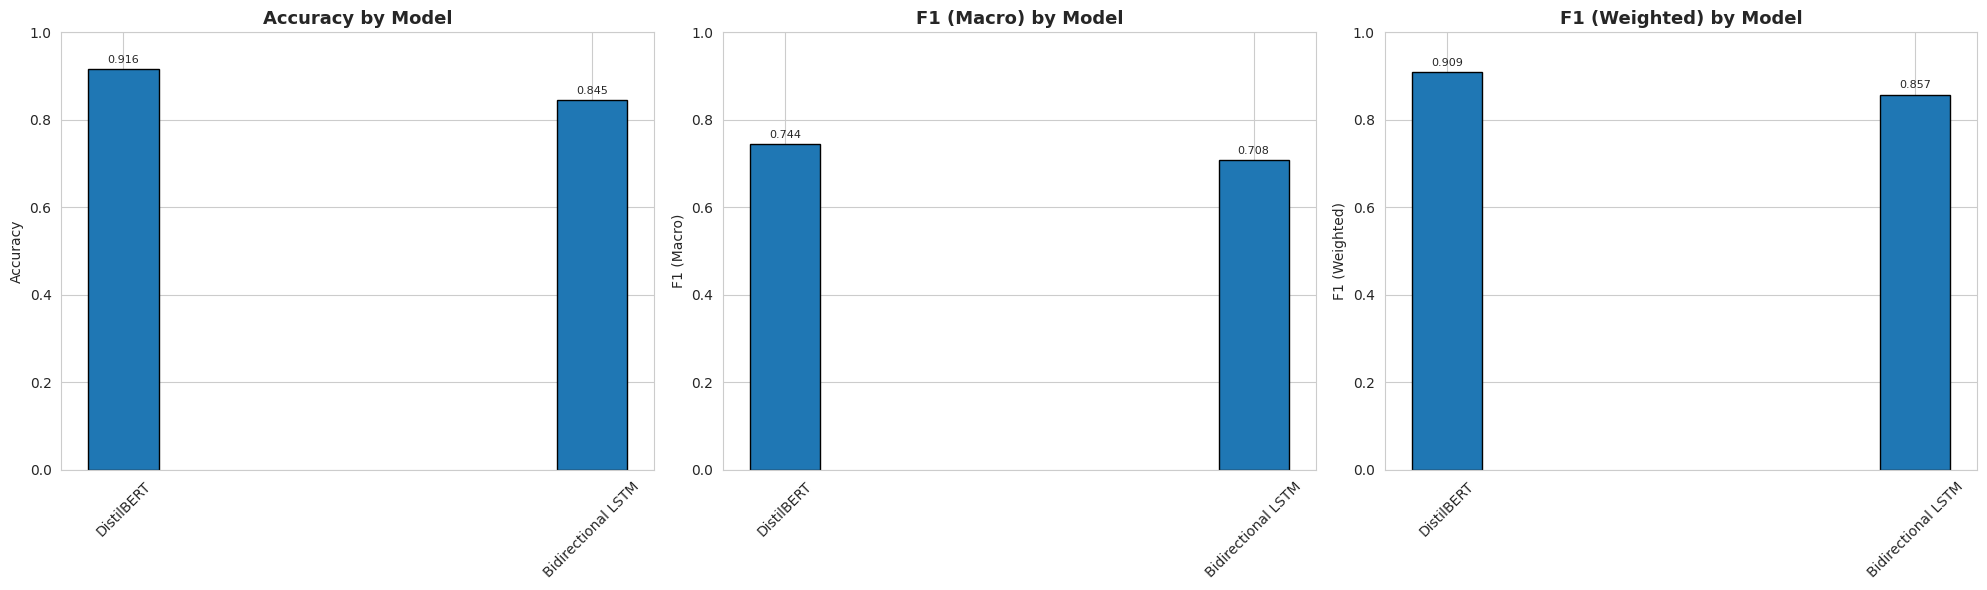

In [ ]:
# ------------------------------------------------------------
# Visualization of model comparison
# ------------------------------------------------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(
        results_df['Model'],
        results_df[metric],
        width=0.15,   # thinner bars
        edgecolor='black'
    )

    ax.set_title(f'{metric} by Model', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ------------------------------------------------------------
# Identify best model
# ------------------------------------------------------------

best_row = results_df.loc[results_df['F1 (Macro)'].idxmax()]

print(f'Best Model (by Macro F1): {best_row["Model"]}')
print(f'  Accuracy:      {best_row["Accuracy"]:.4f}')
print(f'  F1 (Macro):    {best_row["F1 (Macro)"]:.4f}')
print(f'  F1 (Weighted): {best_row["F1 (Weighted)"]:.4f}')

Best Model (by Macro F1): DistilBERT
  Accuracy:      0.9161
  F1 (Macro):    0.7438
  F1 (Weighted): 0.9091


---
## 10. Confusion Matrices

In this section, we visualize confusion matrices for the models.
A confusion matrix shows how many predictions were correct and
where the model made mistakes between classes.


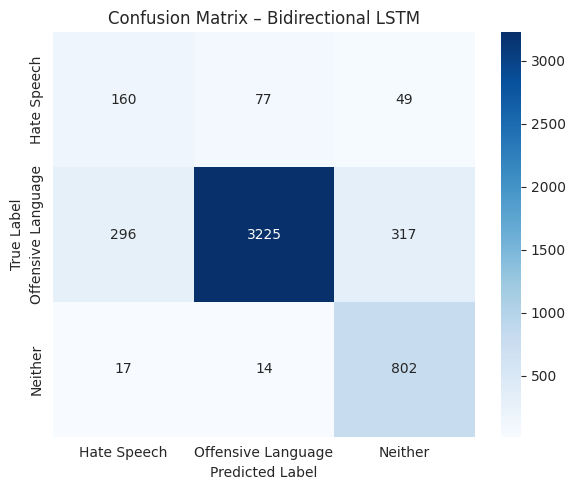

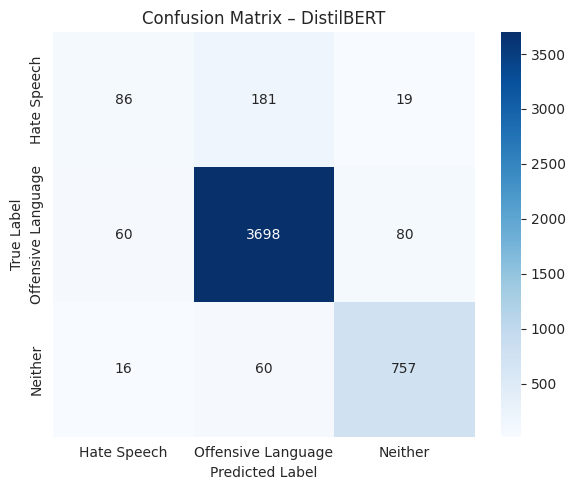

Interpretation:
The confusion matrix helps us understand how the model
classifies each category and where misclassifications occur.
For example, hate speech may sometimes be confused with
offensive language because the wording can be similar.


In [ ]:
# Class labels in this dataset:
# 0 = Hate Speech
# 1 = Offensive Language
# 2 = Neither

class_names = ["Hate Speech", "Offensive Language", "Neither"]


# ------------------------------------------------------------
# Function to plot a confusion matrix
# ------------------------------------------------------------

def plot_confusion_matrix(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 10.1 Confusion Matrix for LSTM
# ------------------------------------------------------------

plot_confusion_matrix(
    y_test,
    lstm_results["y_pred"],
    "Confusion Matrix – Bidirectional LSTM"
)


# ------------------------------------------------------------
# 10.2 Confusion Matrix for DistilBERT
# ------------------------------------------------------------

plot_confusion_matrix(
    y_test,
    bert_results["y_pred"],
    "Confusion Matrix – DistilBERT"
)


# ------------------------------------------------------------
# 10.3 Interpretation
# ------------------------------------------------------------

print("Interpretation:")
print("The confusion matrix helps us understand how the model")
print("classifies each category and where misclassifications occur.")
print("For example, hate speech may sometimes be confused with")
print("offensive language because the wording can be similar.")

:---
## 11. Detailed Analysis of Best Model

In this section, we analyze the performance of the models in more detail.
Instead of feature importance (which is not available for LSTM/BERT),
we examine examples that were misclassified by the models.

This helps us understand why some tweets are difficult to classify.

In [ ]:
# Class label mapping
class_map = {
    0: "Hate Speech",
    1: "Offensive Language",
    2: "Neither"
}

# ------------------------------------------------------------
# 11.1 Identify the best model based on Macro F1
# ------------------------------------------------------------

best_model_name = results_df.sort_values(by="F1 (Macro)", ascending=False).iloc[0]["Model"]

print("Best model selected for detailed analysis:", best_model_name)

# ------------------------------------------------------------
# 11.2 Use predictions from the best model
# ------------------------------------------------------------

if best_model_name == "Bidirectional LSTM":
    y_pred_best = lstm_results["y_pred"]

elif best_model_name == "DistilBERT":
    y_pred_best = bert_results["y_pred"]

else:
    raise ValueError("Best model name not recognized.")

# ------------------------------------------------------------
# 11.3 Print detailed classification report
# ------------------------------------------------------------

print(f"\n=== Detailed Classification Report ({best_model_name}) ===")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=list(class_map.values())
))

Best model selected for detailed analysis: DistilBERT

=== Detailed Classification Report (DistilBERT) ===
                    precision    recall  f1-score   support

       Hate Speech       0.53      0.30      0.38       286
Offensive Language       0.94      0.96      0.95      3838
           Neither       0.88      0.91      0.90       833

          accuracy                           0.92      4957
         macro avg       0.78      0.72      0.74      4957
      weighted avg       0.91      0.92      0.91      4957



---
## 12. Hypothesis Testing & Discussion

### H1: Deep learning models can achieve strong performance in hate speech detection

The results support **H1**. Both deep learning models performed well on the dataset, with DistilBERT achieving the strongest overall performance. They  show both models are effective for hate speech classification, but DistilBERT clearly outperformed the Bidirectional LSTM on all main evaluation metrics.

### H2: Transformer-based models may outperform LSTM models

The results also support **H2**. DistilBERT, a transformer-based model, performed better than the Bidirectional LSTM in accuracy, macro F1, and weighted F1. This suggests that transformer models are better able to capture context and meaning in short social media texts, which is especially useful for distinguishing between similar classes such as hate speech and offensive language.

### Key Observations

1. **Class Imbalance:** Class imbalance remains an important challenge.The dataset contains many more examples of offensive language than hate speech, which makes the hate speech class harder to detect accurately.
2. **DistilBERT was the best-performing model in this project** based on Macro F1-score and overall accuracy. According to the detailed classification report for DistilBERT, the model performed very strongly on Offensive Language and Neither, but the Hate Speech class remained the most difficult:
3. **The Bidirectional LSTM also performed well** but it was weaker than DistilBERT in capturing minority-class patterns.
4. **Model Performance:** The confusion matrices show that some hate speech tweets are still confused with offensive language, which is understandable because the wording in these categories can be similar. Overall, the findings show that DistilBERT is the most effective model in this notebook, while the Bidirectional LSTM still provides a solid deep learning baseline.

In [ ]:
# ------------------------------------------------------------
# Final summary table
# ------------------------------------------------------------

print('\n' + '='*70)
print('FINAL RESULTS SUMMARY')
print('='*70)
print()

print(results_df.sort_values('F1 (Macro)', ascending=False).to_string(index=False))

print()
print('='*70)

best = results_df.loc[results_df['F1 (Macro)'].idxmax()]

print(f'\nBest overall model: {best["Model"]}')
print(f'  -> Accuracy: {best["Accuracy"]:.4f}  |  F1 (Macro): {best["F1 (Macro)"]:.4f}  |  F1 (Weighted): {best["F1 (Weighted)"]:.4f}')


FINAL RESULTS SUMMARY

             Model  Accuracy  F1 (Macro)  F1 (Weighted)
        DistilBERT  0.916078    0.743775       0.909112
Bidirectional LSTM  0.844664    0.708267       0.857097


Best overall model: DistilBERT
  -> Accuracy: 0.9161  |  F1 (Macro): 0.7438  |  F1 (Weighted): 0.9091


---
## 13. Conclusion

In this project, we built and compared two deep learning models for hate speech detection:

**Bidirectional LSTM**

**DistilBERT**

Both models were trained and evaluated on the hate speech dataset using accuracy, macro F1-score, weighted F1-score, classification reports, and confusion matrices.

The final results showed that DistilBERT achieved the best overall performance.

This indicates that transformer-based models such as DistilBERT are more effective than LSTM models for hate speech detection in this dataset, mainly because they capture contextual meaning more effectively.

However, the project also showed that detecting hate speech remains difficult, especially because of: class imbalance overlap between hate speech and offensive language the subtle context of social media text

### Future Work
- Apply **oversampling (SMOTE)** or **class weighting** to handle imbalance
- Perform **hyperparameter tuning** using GridSearchCV
- Test on additional datasets for generalization

---
*Project by Jonathan Bergkvist & Aleksandra Davidova Stefanova*